In [1]:
import pandas as pd
import scipy
from sklearn.linear_model import LogisticRegression
import pickle

from geoai.utils_ds.preprocessing_ops import PreProcessingOperations
from geoai.utils_ml.model_ops import ModelOperations
from geoai.utils_ds.visualize_ops import VisualizeOperations
import warnings
warnings.filterwarnings("ignore")

model_ops = ModelOperations()
pre_ops = PreProcessingOperations()
vis_ops = VisualizeOperations()

In [8]:
X_train = pd.read_csv("csv_files/X_train.csv")
X_test = pd.read_csv("csv_files/X_test.csv")
y_train = pd.read_csv("csv_files/y_train_encoded.csv")
y_test = pd.read_csv("csv_files/y_test_encoded.csv")
X_train.head()

,BLUE,GREEN,RED,NIR,SWIR
0,350.0,542.0000,323.0,3277.0000,1975.3334
1,390.0,555.0000,380.0,3016.6667,1991.0000
2,1177.0,1224.6666,1268.0,1385.0000,1687.4000
3,363.2,546.5000,395.0,3244.5000,2052.0000
4,1095.6,1107.3334,1154.0,1228.0000,1573.0000


In [11]:
X_train_scaled, X_test_scaled = pre_ops.scale_to_minmax(X_train, X_test)
lr = LogisticRegression(solver='lbfgs', max_iter=10000, random_state=1)

<img src="figures/kfold2.jpg" alt="Alt text" width="800" height="500"><style>

 ## K-Fold Cross-Validation

K-Fold Cross-Validation is a robust technique used to evaluate the performance and generalizability of a machine learning model. It involves splitting the dataset into `k` subsets, or "folds," and then using each fold as a validation set while the remaining `k-1` folds are used for training. This process is repeated `k` times, with each fold used exactly once as the validation set.

### How K-Fold Cross-Validation Works

1. **Splitting the Data**: The dataset is randomly divided into `k` equal-sized (or nearly equal) subsets.
2. **Training and Validation**: For each of the `k` iterations:
   - One fold is used as the validation set.
   - The remaining `k-1` folds are used to train the model.
3. **Performance Evaluation**: The model's performance is evaluated using the validation set, and the performance metric (e.g., accuracy, F1 score, RMSE) is recorded.
4. **Averaging Results**: After completing the `k` iterations, the performance metrics from each fold are averaged to produce a single performance estimate.

### Benefits of K-Fold Cross-Validation

- **Improved Model Evaluation**: Provides a more accurate estimate of model performance by reducing the variance associated with a single train-test split.
- **Efficient Use of Data**: Ensures that every data point is used for both training and validation, maximizing the use of available data.
- **Detects Overfitting and Underfitting**: Helps identify issues like overfitting (where the model performs well on training data but poorly on validation data) and underfitting (where the model performs poorly on both training and validation data).

### Example Scenario

Consider a dataset with 1000 samples that you want to use to train a classification model. Using 5-fold cross-validation (`k=5`):

1. **Iteration 1**: Train on folds 2-5, validate on fold 1.
2. **Iteration 2**: Train on folds 1, 3-5, validate on fold 2.
3. **Iteration 3**: Train on folds 1-2, 4-5, validate on fold 3.
4. **Iteration 4**: Train on folds 1-3, 5, validate on fold 4.
5. **Iteration 5**: Train on folds 1-4, validate on fold 5.

The performance metrics from each iteration are averaged to provide a final performance estimate for the model.

In [12]:
mean_acc, std_acc = model_ops.stratify_k_fold_cv(X_train_scaled, y_train, 10, lr)

Fold: 01, Acc.: 0.898
Fold: 02, Acc.: 0.899
Fold: 03, Acc.: 0.868
Fold: 04, Acc.: 0.910
Fold: 05, Acc.: 0.883
Fold: 06, Acc.: 0.872
Fold: 07, Acc.: 0.903
Fold: 08, Acc.: 0.903
Fold: 09, Acc.: 0.925
Fold: 10, Acc.: 0.904

CV accuracy: 0.897 +/- 0.017


<img src="figures/learning_curves.jpg" alt="Alt text" width="600" height="500"><style>

## Learning Curves

Learning curves are graphical representations that show the performance of a machine learning model over time, typically as a function of the number of training examples or training iterations. They are used to diagnose model behavior, identify potential issues such as overfitting or underfitting, and guide the tuning of model parameters.

### Key Components of Learning Curves

1. **Training Score**: The model's performance on the training dataset, plotted as a function of the number of training examples or iterations.
2. **Validation Score**: The model's performance on a separate validation dataset, plotted alongside the training score to compare how well the model generalizes to unseen data.

### How to Interpret Learning Curves

1. **High Training and Validation Scores**: Indicates that the model is performing well, with both high accuracy and good generalization to new data.
2. **High Training Score, Low Validation Score**: Suggests overfitting, where the model performs well on the training data but poorly on the validation data. This can be addressed by using more training data, simplifying the model, or applying regularization techniques.
3. **Low Training and Validation Scores**: Indicates underfitting, where the model is not capturing the underlying patterns in the data. This can be improved by increasing model complexity, selecting better features, or allowing more training iterations.

### Benefits of Learning Curves

- **Diagnose Model Performance**: Helps in understanding how well the model is learning and where it might be failing.
- **Guide Hyperparameter Tuning**: Provides insights into how changes in model parameters or training data size affect performance, guiding more effective tuning.
- **Optimize Training Process**: Identifies the point where adding more training data no longer significantly improves performance, optimizing the training process.


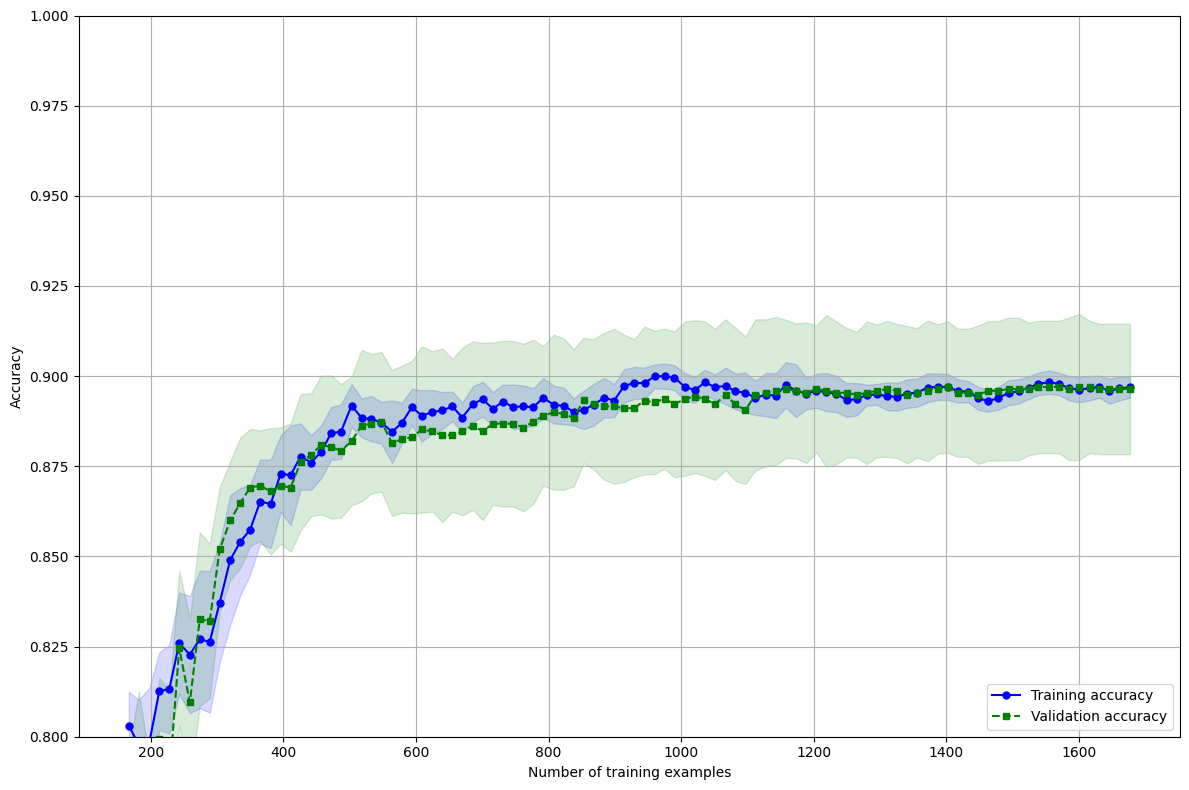

In [13]:
ylim = [0.8, 1.0]
train_sizes, train_mean, train_std, test_mean, test_std = model_ops.compute_metrics_for_learning_curve(X_train_scaled, y_train, lr)
vis_ops.plot_learning_curve(train_sizes, train_mean, train_std, test_mean, test_std, ylim)

## Validation Curves

Validation curves are graphical representations that show the relationship between a model's performance and a particular hyperparameter. They are used to understand how changes in the hyperparameter values affect the model's training and validation performance, helping to identify the best hyperparameter values to optimize the model.

### Key Components of Validation Curves

1. **X-Axis (Hyperparameter Values)**: Represents different values of the hyperparameter being analyzed.
2. **Y-Axis (Performance Score)**: Represents the model's performance score, such as accuracy, F1 score, or mean squared error.
3. **Training Score Curve**: Shows the model's performance on the training data for different hyperparameter values.
4. **Validation Score Curve**: Shows the model's performance on the validation data for different hyperparameter values.

### How to Interpret Validation Curves

1. **Training and Validation Scores Converge**: When both the training and validation scores are high and close to each other, it indicates a well-performing model with an optimal hyperparameter value.
2. **High Training Score, Low Validation Score**: Indicates overfitting, where the model performs well on the training data but poorly on the validation data. This occurs when the hyperparameter value makes the model too complex.
3. **Low Training and Validation Scores**: Indicates underfitting, where the model performs poorly on both the training and validation data. This occurs when the hyperparameter value makes the model too simple.

### Benefits of Validation Curves

- **Hyperparameter Tuning**: Helps in identifying the optimal range of hyperparameter values that balance the trade-off between bias and variance.
- **Model Diagnosis**: Provides insights into whether the model is overfitting or underfitting, guiding necessary adjustments.
- **Improved Performance**: By fine-tuning hyperparameters, validation curves help in improving the model's performance and generalization to new data.

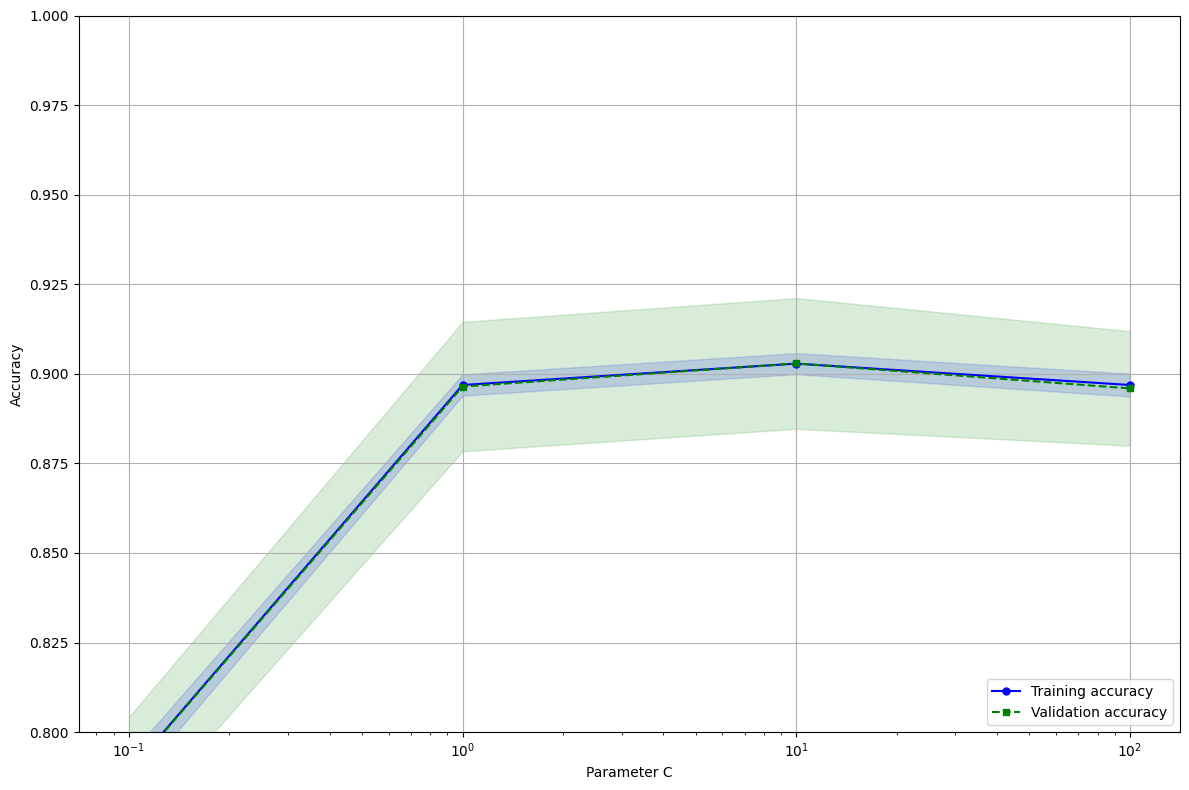

In [20]:
param_range = [0.1, 1, 10, 100]
train_mean, train_std, test_mean, test_std = model_ops.compute_metric_for_validation_curve(
    X_train_scaled, y_train, param_range, "C", lr
)
vis_ops.plot_validation_curve(
    param_range, train_mean, train_std, test_mean, test_std, 
)

## Hyperparameter Tuning: Grid Search and Randomized Search

Hyperparameter tuning is a crucial step in optimizing machine learning models. Two popular methods for hyperparameter tuning are Grid Search and Randomized Search. Both methods systematically explore different combinations of hyperparameters to find the best set that maximizes model performance.

### Grid Search

Grid Search is an exhaustive search method that evaluates all possible combinations of specified hyperparameter values. It systematically works through multiple combinations, ensuring that the best parameters are found.

#### How Grid Search Works

1. **Define the Hyperparameter Space**: Specify a range of values for each hyperparameter.
2. **Evaluate Combinations**: Train the model using every possible combination of hyperparameter values.
3. **Select Best Parameters**: Identify the combination of hyperparameters that results in the best model performance, typically measured using cross-validation.

#### Pros and Cons of Grid Search

- **Pros**:
  - **Comprehensive**: Evaluates all possible combinations, ensuring that the optimal set of hyperparameters is found.
  - **Simple to Implement**: Easy to set up and understand.

- **Cons**:
  - **Computationally Expensive**: Can be very time-consuming and resource-intensive, especially with a large number of hyperparameters and values.
  - **Scalability**: Not practical for large hyperparameter spaces.

### Randomized Search

Randomized Search is a more efficient method that evaluates a random subset of the hyperparameter space. Instead of trying all possible combinations, it randomly selects a fixed number of combinations to evaluate.

#### How Randomized Search Works

1. **Define the Hyperparameter Space**: Specify the range or distribution for each hyperparameter.
2. **Random Sampling**: Randomly sample a fixed number of combinations from the hyperparameter space.
3. **Evaluate Combinations**: Train the model using the randomly selected combinations.
4. **Select Best Parameters**: Identify the combination of hyperparameters that results in the best model performance.

#### Pros and Cons of Randomized Search

- **Pros**:
  - **Efficiency**: Requires fewer iterations compared to Grid Search, making it faster and less computationally intensive.
  - **Scalable**: More practical for large hyperparameter spaces and complex models.

- **Cons**:
  - **Non-Exhaustive**: May miss the optimal combination since it does not evaluate all possible combinations.
  - **Randomness**: Performance can vary depending on the random samples chosen.

<img src="figures/gridsearch.jpg" alt="Alt text" width="900" height="500"><style>

In [22]:
lr = LogisticRegression(multi_class='auto')
param_grid = {
    'C': [0.1, 1, 10, 100],
    'solver': ['newton-cg', 'lbfgs', 'liblinear', 'saga'],
     'max_iter': [100, 200, 300, 400, 500],
}
best_params, best_score = model_ops.find_best_hyperparameters_gs(X_train_scaled, y_train, lr, param_grid, "f1_weighted")
print(best_params, best_score)


{'C': 10, 'max_iter': 100, 'solver': 'lbfgs'} 0.9034126100190356


# Tuning hyperparameters via randomized search

In [24]:
param_grid = {
    'C': scipy.stats.loguniform(0.01, 1000.0),
    'solver': ['newton-cg', 'lbfgs', 'liblinear', 'saga'],
     'max_iter': list(range(100, 510, 10)),
}
best_params, best_score = model_ops.find_best_hyperparameters_rs(X_train_scaled, y_train, lr, param_grid, "f1_weighted")
print(best_params, best_score)

{'C': 9.232675920286502, 'max_iter': 160, 'solver': 'lbfgs'} 0.9023539659198981


# Find the final accuracy of the model

In [25]:
best_params = {'C': 10, 'max_iter': 100, 'solver': 'lbfgs'}
lr_optimized = LogisticRegression(**best_params)

lr_optimized.fit(X_train_scaled, y_train)
y_train_pred = lr_optimized.predict(X_train_scaled)
y_pred_test = lr_optimized.predict(X_test_scaled)

# calculate the accuracy
print(f"Train Accuracy: {model_ops.calculate_classification_accuracy(y_train, y_train_pred)[3]}")
print(f"Test Accuracy: {model_ops.calculate_classification_accuracy(y_test, y_pred_test)[3]}")

Train Accuracy: 0.9039994925015031
Test Accuracy: 0.8976668239594334


Several hyperparamter frameworks are available such as Optuna and HyperOpt.

END